# Import libraries

In [1]:
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from statsmodels.nonparametric.smoothers_lowess import lowess

# Scrape data from Wikipedia
url = "https://en.wikipedia.org/wiki/Opinion_polling_for_the_2026_Hungarian_parliamentary_election"

headers = {"User-Agent": "Mozilla/5.0"}
html = requests.get(url, headers=headers, timeout=20).text
soup = BeautifulSoup(html, "html.parser")

# First scrapping of Wikipedia tables

In [2]:
# Based on inspect
target_table = soup.select_one(
    "table.wikitable.mw-collapsible.sortable.sticky-header-multi"
)

In [3]:
tables = soup.find_all("table", class_="wikitable")

print("tables found:", len(tables))

tables found: 52


In [4]:
# pick the table with 2026 poll rows
best_table = None
best_score = 0

for table in tables:
    rows_2026 = 0

    for tr in table.find_all("tr"):
        cells = tr.find_all(["td", "th"])
        text = " ".join(c.get_text(" ", strip=True) for c in cells)

        if "2026" in text and ("Government" in text or "Independent" in text or "National Election" in text):
            rows_2026 += 1

    if rows_2026 > best_score:
        best_score = rows_2026
        best_table = table

target_table = best_table

print("best score:", best_score)

rows = []

for tr in target_table.find_all("tr"):
    cells = tr.find_all("td")

    if len(cells) != 11:
        continue

    row = [c.get_text(" ", strip=True) for c in cells]

    fieldwork_date = row[0]
    polling_firm = row[1]

    if "2022" in fieldwork_date:
        break

    if "2026" not in fieldwork_date:
        continue

    if polling_firm == "National Election":
        continue

    rows.append({
        "fieldwork_date": fieldwork_date,
        "polling_firm": polling_firm,
        "affiliation": row[2],
        "sample_size": row[3],
        "fidesz": row[4],
        "tisza": row[5],
        "dk": row[6],
        "mh": row[7],
        "mkkp": row[8],
        "others": row[9],
        "lead": row[10],
    })

initial_df = pd.DataFrame(rows)

def clean_number(x):
    x = str(x).replace(",", "").replace("–", "").replace("%", "")
    match = re.search(r"-?\d+(?:\.\d+)?", x)
    return float(match.group()) if match else None

for col in ["sample_size", "fidesz", "tisza", "dk", "mh", "mkkp", "others", "lead"]:
    initial_df[col] = initial_df[col].apply(clean_number)

initial_df = initial_df.reset_index(drop=True)

initial_df

best score: 48


,fieldwork_date,polling_firm,affiliation,sample_size,fidesz,tisza,dk,mh,mkkp,others,lead
0,9–11 Apr 2026,Alapjogokért Központ [ better source needed ],Government,1000.0,44.5,42.0,4.0,7.0,2.5,NaN,2.5
1,8–11 Apr 2026,21 Kutatóközpont,Independent/opposition,1500.0,38.0,55.0,1.0,5.0,1.0,NaN,17.0
2,7–11 Apr 2026,Medián,Independent/opposition,2286.0,37.9,55.5,1.4,3.9,1.3,NaN,17.6
3,7–10 Apr 2026,Minerva,Independent/opposition,3332.0,41.1,50.8,1.7,4.2,2.3,NaN,9.7
4,5–10 Apr 2026,AtlasIntel,Independent/opposition,1587.0,39.3,52.1,1.5,5.1,1.4,0.6,12.8
5,7–9 Apr 2026,Závecz Research,Independent/opposition,1000.0,40.0,54.0,1.0,4.0,1.0,NaN,14.0
6,7–9 Apr 2026,Publicus,Independent/opposition,1004.0,39.0,52.0,2.0,5.0,2.0,NaN,13.0
7,7 Apr 2026,McLaughlin & Associates,Government,1000.0,45.4,39.7,4.6,7.5,2.2,0.6,5.7
8,31 Mar–4 Apr 2026,Iránytű Institute,Independent/opposition,1000.0,40.0,51.0,1.0,4.0,4.0,0.0,11.0
9,29 Mar–4 Apr 2026,IDEA,Independent/opposition,1500.0,37.0,50.0,4.0,5.0,2.0,2.0,13.0


In [5]:
print(initial_df.columns)

Index(['fieldwork_date', 'polling_firm', 'affiliation', 'sample_size',
       'fidesz', 'tisza', 'dk', 'mh', 'mkkp', 'others', 'lead'],
      dtype='object')


# Date reworking and cutoff

In [6]:
# Date rework for filtering

def extract_end_date(date_str):

    date_str = str(date_str).strip()

    # normalize dash
    date_str = date_str.replace("–", "-")

    # Case: 9-11 Apr 2026
    m = re.search(
        r"(\d+)-(\d+)\s+([A-Za-z]{3})\s+(20\d{2})",
        date_str
    )

    if m:
        start_day, end_day, month, year = m.groups()

        return pd.to_datetime(
            f"{end_day} {month} {year}",
            format="%d %b %Y"
        )

    # Case: 31 Mar-4 Apr 2026
    m = re.search(
        r"(\d+)\s+([A-Za-z]{3})-(\d+)\s+([A-Za-z]{3})\s+(20\d{2})",
        date_str
    )

    if m:
        d1, m1, d2, m2, year = m.groups()

        return pd.to_datetime(
            f"{d2} {m2} {year}",
            format="%d %b %Y"
        )

    # Case: 7 Apr 2026
    m = re.search(
        r"(\d+)\s+([A-Za-z]{3})\s+(20\d{2})",
        date_str
    )

    if m:
        day, month, year = m.groups()

        return pd.to_datetime(
            f"{day} {month} {year}",
            format="%d %b %Y"
        )

    return pd.NaT

initial_df["end_date"] = (
    initial_df["fieldwork_date"]
    .apply(extract_end_date)
)

print(
    initial_df[
        ["fieldwork_date", "end_date"]
    ].head(20)
)

       fieldwork_date   end_date
0       9–11 Apr 2026 2026-04-11
1       8–11 Apr 2026 2026-04-11
2       7–11 Apr 2026 2026-04-11
3       7–10 Apr 2026 2026-04-10
4       5–10 Apr 2026 2026-04-10
5        7–9 Apr 2026 2026-04-09
6        7–9 Apr 2026 2026-04-09
7          7 Apr 2026 2026-04-07
8   31 Mar–4 Apr 2026 2026-04-04
9   29 Mar–4 Apr 2026 2026-04-04
10     27–30 Mar 2026 2026-03-30
11     28–29 Mar 2026 2026-03-29
12     24–28 Mar 2026 2026-03-28
13     23–28 Mar 2026 2026-03-28
14     26–27 Mar 2026 2026-03-27
15     23–26 Mar 2026 2026-03-26
16     23–24 Mar 2026 2026-03-24
17     17–20 Mar 2026 2026-03-20
18     16–17 Mar 2026 2026-03-17
19     10–11 Mar 2026 2026-03-11


In [7]:
initial_df

,fieldwork_date,polling_firm,affiliation,sample_size,fidesz,tisza,dk,mh,mkkp,others,lead,end_date
0,9–11 Apr 2026,Alapjogokért Központ [ better source needed ],Government,1000.0,44.5,42.0,4.0,7.0,2.5,NaN,2.5,2026-04-11
1,8–11 Apr 2026,21 Kutatóközpont,Independent/opposition,1500.0,38.0,55.0,1.0,5.0,1.0,NaN,17.0,2026-04-11
2,7–11 Apr 2026,Medián,Independent/opposition,2286.0,37.9,55.5,1.4,3.9,1.3,NaN,17.6,2026-04-11
3,7–10 Apr 2026,Minerva,Independent/opposition,3332.0,41.1,50.8,1.7,4.2,2.3,NaN,9.7,2026-04-10
4,5–10 Apr 2026,AtlasIntel,Independent/opposition,1587.0,39.3,52.1,1.5,5.1,1.4,0.6,12.8,2026-04-10
5,7–9 Apr 2026,Závecz Research,Independent/opposition,1000.0,40.0,54.0,1.0,4.0,1.0,NaN,14.0,2026-04-09
6,7–9 Apr 2026,Publicus,Independent/opposition,1004.0,39.0,52.0,2.0,5.0,2.0,NaN,13.0,2026-04-09
7,7 Apr 2026,McLaughlin & Associates,Government,1000.0,45.4,39.7,4.6,7.5,2.2,0.6,5.7,2026-04-07
8,31 Mar–4 Apr 2026,Iránytű Institute,Independent/opposition,1000.0,40.0,51.0,1.0,4.0,4.0,0.0,11.0,2026-04-04
9,29 Mar–4 Apr 2026,IDEA,Independent/opposition,1500.0,37.0,50.0,4.0,5.0,2.0,2.0,13.0,2026-04-04


In [8]:
# Considering dates up to 1 week before the election

cutoff_date = pd.Timestamp("2026-04-05")

model_df = initial_df[
    initial_df["end_date"] <= cutoff_date
].copy()

# Vetting

In [9]:
pollster_meta = pd.read_excel("pollster-backgroundcheck.xlsx")

pollster_meta.head()

,firm,conflict,remove,source 1,source 2
0,Republikon,none proven,no,NaN,NaN
1,Medián,none proven,no,NaN,NaN
2,Nézőpont,owner part of propaganda state,yes,https://www.nytimes.com/2025/10/12/world/europ...,NaN
3,Minerva,none proven,no,NaN,NaN
4,XXI. Század,"KKETTKA funds, Orban staffer",yes,http://www.magyarkozlony.hu/pdf/5191,https://www.democracyculturefoundation.org/who...


In [10]:
model_df = model_df.merge(
    pollster_meta[["firm", "remove"]],
    left_on="polling_firm",
    right_on="firm",
    how="left"
)

In [11]:
# Two different subsets for modeling
all_polls_df = model_df.copy()

filtered_polls_df = model_df[
    model_df["remove"] != "yes"
].copy()

all_polls_df = all_polls_df.drop(columns="firm")
filtered_polls_df = filtered_polls_df.drop(columns="firm")

In [12]:
filtered_polls_df

,fieldwork_date,polling_firm,affiliation,sample_size,fidesz,tisza,dk,mh,mkkp,others,lead,end_date,remove
1,29 Mar–4 Apr 2026,IDEA,Independent/opposition,1500.0,37.0,50.0,4.0,5.0,2.0,2.0,13.0,2026-04-04,no
2,27–30 Mar 2026,Publicus,Independent/opposition,1002.0,40.0,49.0,3.0,6.0,3.0,NaN,9.0,2026-03-30,no
4,24–28 Mar 2026,Závecz Research,Independent/opposition,1000.0,38.0,51.0,3.0,5.0,3.0,NaN,13.0,2026-03-28,no
7,23–26 Mar 2026,Republikon,Independent/opposition,1000.0,40.0,49.0,2.0,5.0,4.0,NaN,9.0,2026-03-26,no
9,17–20 Mar 2026,Medián,Independent/opposition,1000.0,35.0,58.0,1.0,4.0,2.0,NaN,23.0,2026-03-20,no
11,10–11 Mar 2026,Minerva,Independent/opposition,1000.0,40.1,51.3,1.4,5.5,1.7,NaN,11.2,2026-03-11,no
14,28 Feb–6 Mar 2026,IDEA,Independent/opposition,1500.0,37.0,49.0,5.0,6.0,2.0,1.0,12.0,2026-03-06,no
16,22–28 Feb 2026,Závecz Research,Independent/opposition,1000.0,38.0,50.0,3.0,7.0,2.0,NaN,12.0,2026-02-28,no
17,24–27 Feb 2026,Publicus,Independent/opposition,1001.0,39.0,47.0,4.0,6.0,4.0,NaN,8.0,2026-02-27,no
19,20–25 Feb 2026,Minerva,Independent/opposition,1200.0,41.5,50.0,2.8,4.1,1.7,NaN,8.5,2026-02-25,no


# Visualization

In [88]:
party_cols = ["fidesz", "tisza", "dk", "mh", "mkkp"]

party_labels = {
    "fidesz": "Fidesz-KDNP",
    "tisza": "TISZA",
    "dk": "DK",
    "mh": "MH",
    "mkkp": "MKKP",
}

party_colors = {
    "fidesz": "#E94E1B",
    "tisza": "#003399",
    "dk": "#0097DA",
    "mh": "#6CC24A",
    "mkkp": "#808080",
}

def prepare_long_df(df):
    long_df = df.melt(
        id_vars=["end_date", "polling_firm", "sample_size"],
        value_vars=party_cols,
        var_name="party",
        value_name="vote_share"
    )

    long_df["vote_share"] = pd.to_numeric(long_df["vote_share"], errors="coerce")
    long_df["sample_size"] = pd.to_numeric(long_df["sample_size"], errors="coerce")

    return long_df.dropna(subset=["end_date", "vote_share"])


def add_trend(long_df, frac=0.25):

    trend_frames = []

    for party in long_df["party"].unique():

        party_df = (
            long_df[long_df["party"] == party]
            .sort_values("end_date")
            .copy()
        )

        # convert dates to numeric for LOWESS
        x = mdates.date2num(party_df["end_date"])
        y = party_df["vote_share"]

        smoothed = lowess(
            y,
            x,
            frac=frac,
            return_sorted=False
        )

        party_df["trend"] = smoothed

        trend_frames.append(party_df)

    return pd.concat(trend_frames)

def plot_polling_trend(df, title, dek, output_path=None):

    long_df = prepare_long_df(df)
    trend_df = add_trend(long_df)

    fig, ax = plt.subplots(figsize=(10, 6))

    for party in party_cols:

        party_raw = long_df[
            long_df["party"] == party
        ]

        party_trend = trend_df[
            trend_df["party"] == party
        ]

        # raw polls
        ax.scatter(
            party_raw["end_date"],
            party_raw["vote_share"],
            alpha=0.22,
            s=22,
            color=party_colors[party]
        )

        # smooth trend
        ax.plot(
            party_trend["end_date"],
            party_trend["trend"],
            linewidth=3,
            color=party_colors[party],
            label=party_labels[party]
        )

    fig.suptitle(title, fontsize=16, y=0.995)

    if dek:
        fig.text(
            0.5,
            0.93,
            dek,
            ha="center",
            fontsize=12,
            color="dimgray"
        )

    ax.set_ylabel("Voting intention (%)", fontsize=11)
    ax.set_xlabel("2026", fontsize=11)
    
    ax.set_ylim(0, 60)

    # cleaner date formatting
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    ax.tick_params(axis="x", labelsize=11)

    ax.grid(True, alpha=0.2)

    ax.legend(
        title=None,
        frameon=True,
        fontsize=12
    )

    ax.set_xlim(
        long_df["end_date"].min() - pd.Timedelta(days=5),
        long_df["end_date"].max() + pd.Timedelta(days=5)
    )  
     
    fig.subplots_adjust(top=0.90) 
       
    if output_path:
        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

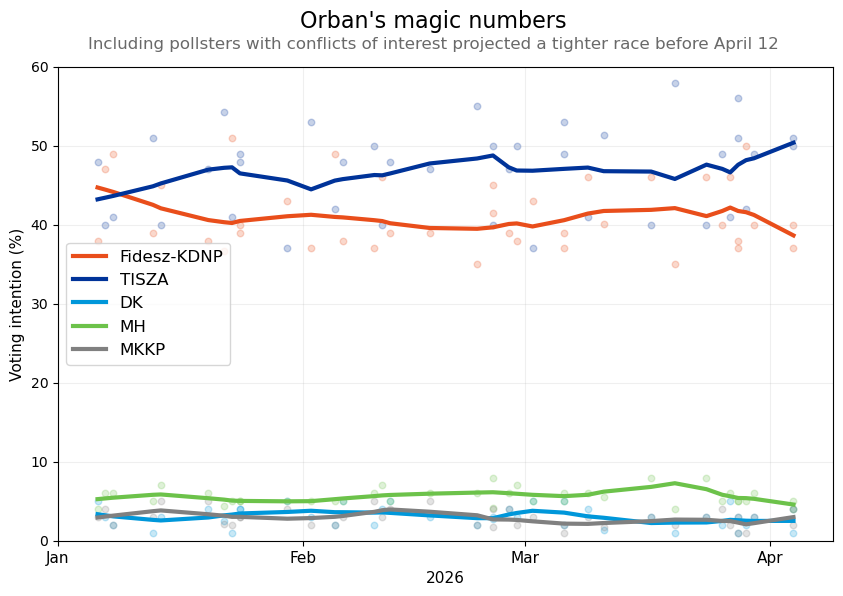

In [92]:
plot_polling_trend(
    all_polls_df,
    title="Orban's magic numbers",
    dek="Including pollsters with conflicts of interest projected a tighter race before April 12",
    output_path="figures/hungary_trend_with_excluded.png"
)

#orban's magic numbers, trends including leaning pollsters produced a tighter race before April 12

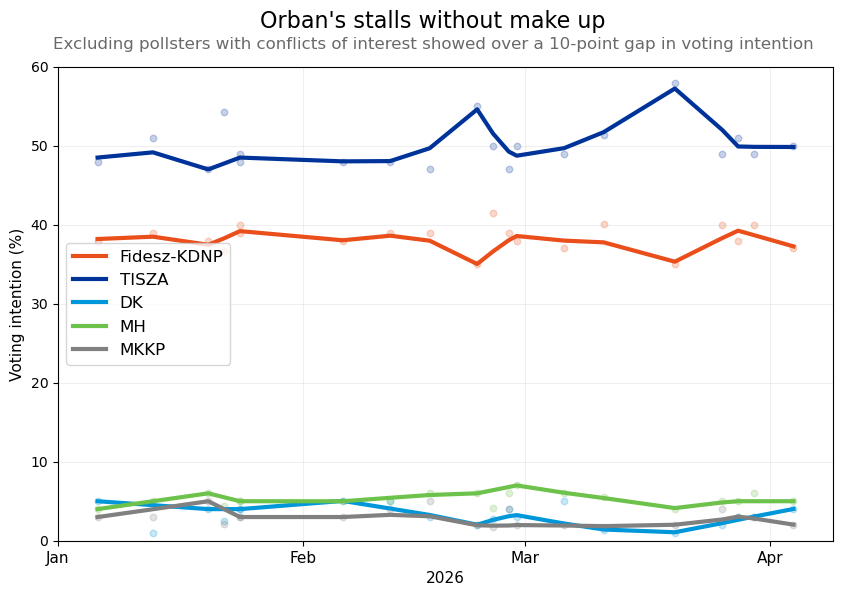

In [91]:
plot_polling_trend(
    filtered_polls_df,
    title="Orban's stalls without make up",
    dek="Excluding pollsters with conflicts of interest showed over a 10-point gap in voting intention",
    output_path="figures/hungary_trend_without_excluded.png"
)

#orban's stalls without make up, trends excluding leaning pollsters showed over a 10-point gap before the election